## AISE4010- Assignment2 - Time Series Forecasting using CNN, RNN, LSTM and GRU

## Grade: 100 points

### Instructions

#### Follow These Steps before submitting your assignment 

1. Complete the notebook.

2. Make sure all plots have axis labels.

3. Once the notebook is complete, `Restart` your kernel by clicking 'Kernel' > 'Restart & Run All'.

4. Fix any errors until your notebook runs without any problems.

5. Submit one completed notebook for the group to OWL by the deadline.

6. Make sure to reference all external code and documentation used.

### Dataset

The `StockData.csv` represents a time series dataset designed to simulate the behavior of stock prices over a period of 1000 days, starting from January 1, 2023. This dataset includes key features commonly found in stock market data, such as opening prices, closing prices, daily highs, daily lows, and trading volume. 

Features:
- Date: The timestamp representing the specific day for each record.
- Open: The stock's price at the start of the trading day. 
- High: The highest price of the stock during the trading day. It is generally higher than the opening price, reflecting intraday market movements.
- Low: The lowest price of the stock during the trading day. It is usually lower than the opening price, capturing downward movements in the market.
- Close: The stock’s price at the end of the trading day. This price reflects the market's closing valuation and fluctuates within a range close to the opening price.
- Volume: The number of shares traded during the day.

### Question 1 - Data Preprocessing (15%)
- Q1.1 Load the provided dataset and plot the `Closing prices` time series. (5%)
- Q1.2 (5%): 

  - a) Decompose the time series into its components and explain them.  
  - b) What do the trend and seasonality components tell you about the overall behavior of the time series? How does understanding     these components help in selecting a model for time series forecasting?
- Q1.3 Restructure the time series using a sliding window approach (with size 10) to prepare it for supervised learning. Split the `Closing prices` time series into 80% for training and 20% for testing. (5%)


Dataset sample:
                  Open        High        Low       Close  Volume
Date                                                             
2023-01-01  102.483571  105.911957  99.423692  106.579055    1132
2023-01-02   99.708883  108.134328  93.337217  100.398438    3838
2023-01-03  104.038482  109.522783  94.684843  106.660228    3696
2023-01-04  108.814281  110.507805  99.452025  111.932348    4385
2023-01-05  100.426345  101.953304  96.349198   98.844836    4770


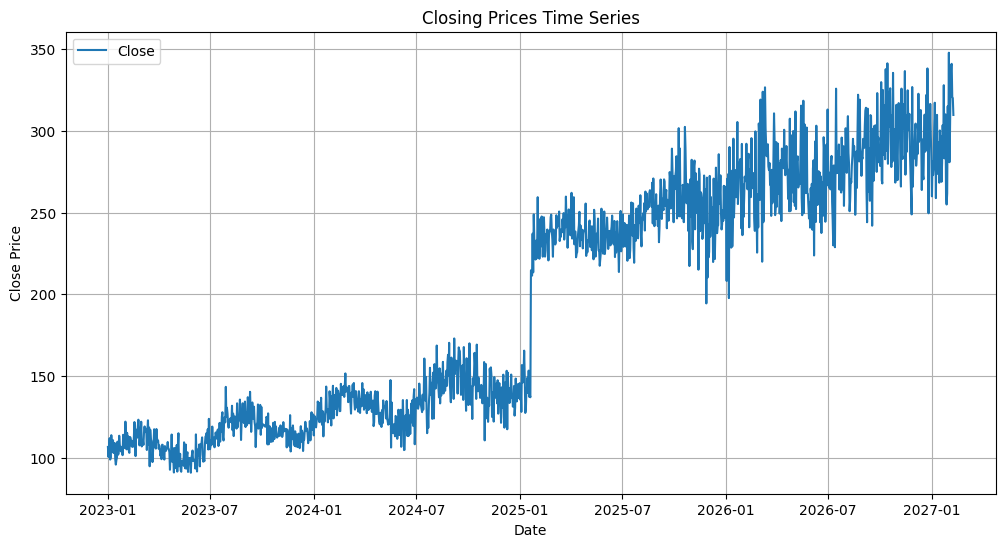

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset 
df = pd.read_csv('StockData.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Quick head check (prints first 5 rows)
print('Dataset sample:')
print(df.head())

# Plot closing prices time series with axis labels
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close')
plt.title('Closing Prices Time Series')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()

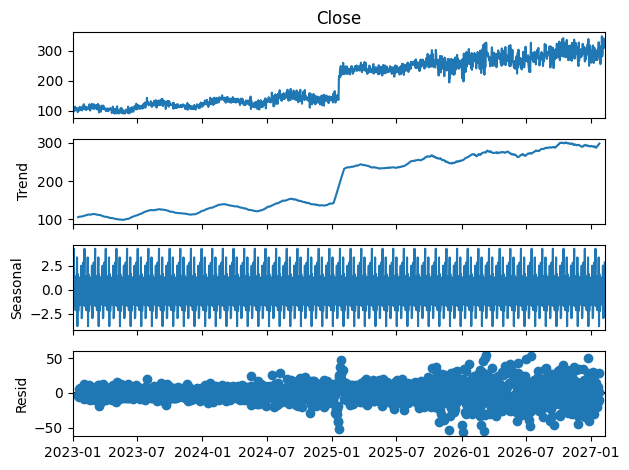

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition  (period = 30 for monthly seasonality in daily data)
decomposition = seasonal_decompose(df["Close"], model='additive', period=30)

# Plot the decomposed components
decomposition.plot()
plt.tight_layout()
plt.show()


*Write your Answer to Q1.2-b here:*
The decomposition splits the time series into three key components:
* Trend: The long term direction of the data
* Seasonality: The repeating patterns at fixed intervals
* Residual: The random fluctuations not explained by trend or seasonality

Based on these components, it can help select our model.
Ie: if the data shows a strong trend, models like ARIMA are appropriate. If seasonality is strong, seasonality or seasonal decomposition should be considered. 
Recognizing residual noise will help determine if any further preprocessing is needed.

In our model we see noticeable jumps and seasonal oscillations. These strong trends make us learn more towards a SARIMA, LSTM or CNN could be good selections.

In [8]:
import numpy as np

# Extract the series
data = df["Close"].values

window_size = 10

# Create sliding window dataset
def sliding_window(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = sliding_window(data, window_size)

# Split into 80% training and 20% testing
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Testing shape:", y_test.shape)


Training samples: 1192
Testing samples: 298
Testing shape: (298,)


### Question2 - 1D Convolutional Neural Network (CNN) (20%)
- Q2.1 Create a 1D CNN model for time series forecasting. The model should have two convolutional layers of size 64 and 32 and kernel size of 3, fully connected layer of size 50, droup out of 0.3, and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 32, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q2.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q2.3 How does the 1D-CNN perform in terms of capturing short-term dependencies? Based on the RMSE and MAE values, do you think this model can effectively capture long-term trends? Why or why not? (2%)


Epoch 1/50


C:\Users\Callu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 22419.6875 - val_loss: 447.2344
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 22419.6875 - val_loss: 447.2344
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1959.3362 - val_loss: 676.6136
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1959.3362 - val_loss: 676.6136
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1299.2046 - val_loss: 526.9971
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1299.2046 - val_loss: 526.9971
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1288.4813 - val_loss: 568.9169
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1288.4813 - val_loss: 568.9169
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 990.3884 - val_loss: 450.0602
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 990.3884 - val_loss: 450.0602
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1019.8211 - val_loss: 417.9047
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━

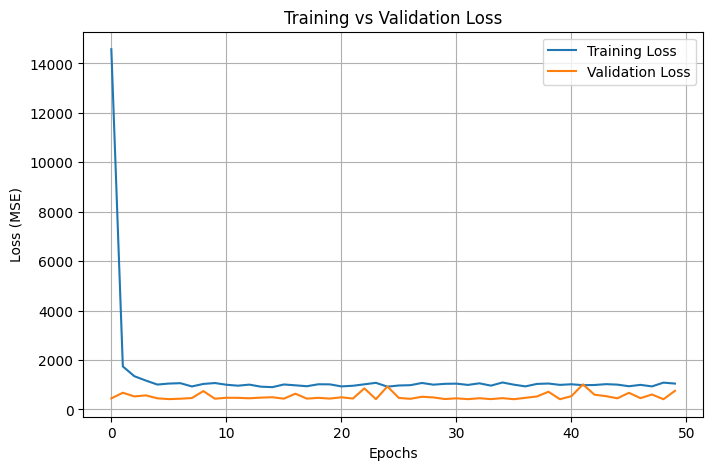

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Reshape input for CNN: (samples, timesteps, features)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Output layer for regression
])

# Compile model
model.compile(optimizer=Adam(), loss='mse')

# Train model
history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Root Mean Squared Error (RMSE): 29.8882
Mean Absolute Error (MAE): 24.1290
Root Mean Squared Error (RMSE): 29.8882
Mean Absolute Error (MAE): 24.1290


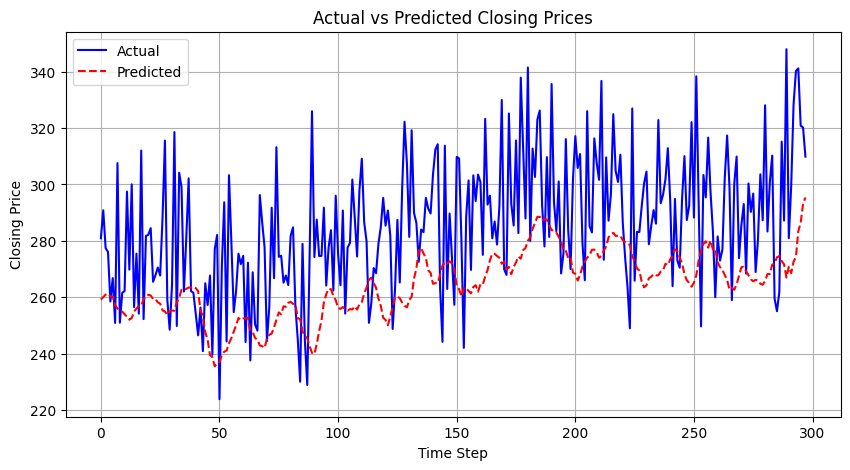

Relative RMSE: 10.48%


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions
y_pred = model.predict(X_test_cnn)

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Plot predictions vs actual values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred, label="Predicted", color="red", linestyle='--')
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q2.3 Here:*
The 1D-CNN model is well suited for capturing short term dependencies in the time series because the filters help detect short-term trends, peaks, or dips efficiently. However, CNN's are not designed to capture long term dependencies, since we are limited to a few time steps. 

### Question 3 - Recurrent Neural Networks (RNN) (20%)
- Q3.1 Create an RNN model for time series forecasting. The model should include a SimpleRNN layer of size 40 and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q3.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q3.3 Why did we use a smaller batch size compared to CNN model. Why might RNN struggle with long-term dependencies, and how is this reflected in the evaluation metrics? (2%)


Epoch 1/50


C:\Users\Callu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11283.0479 - val_loss: 555.0990
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11283.0479 - val_loss: 555.0990
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113.8607 - val_loss: 413.4964
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113.8607 - val_loss: 413.4964
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 93.8548 - val_loss: 462.9149
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 93.8548 - val_loss: 462.9149
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 94.1940 - val_loss: 431.4127
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 94.1940 - val_loss: 431.4127
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 92.6384 - val_loss: 410.8364
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 92.6384 - val_loss: 410.8364
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.5170 - val_loss: 418.3418
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

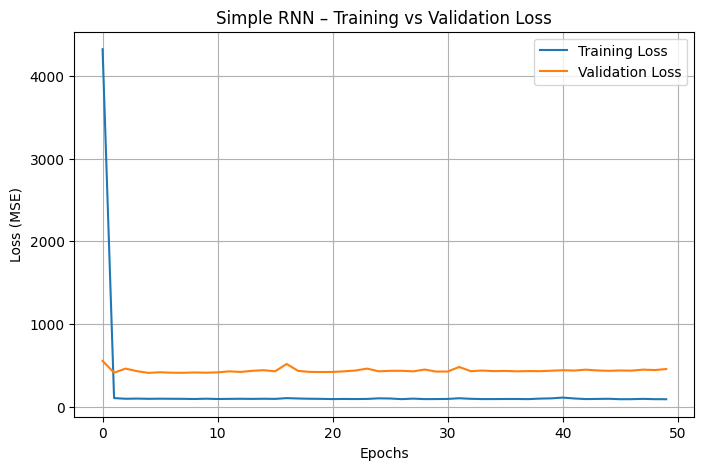

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Reshape data for RNN: (samples, timesteps, features)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# Build Simple RNN model
model_rnn = Sequential([
    SimpleRNN(40, activation='relu', input_shape=(X_train_rnn.shape[1], 1)),
    Dense(1)   # Output layer for regression
])

# Compile the model
model_rnn.compile(optimizer=Adam(), loss='mse')

# Train the model
history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("Simple RNN – Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Root Mean Squared Error (RMSE): 22.3440
Mean Absolute Error (MAE): 17.7171
Root Mean Squared Error (RMSE): 22.3440
Mean Absolute Error (MAE): 17.7171


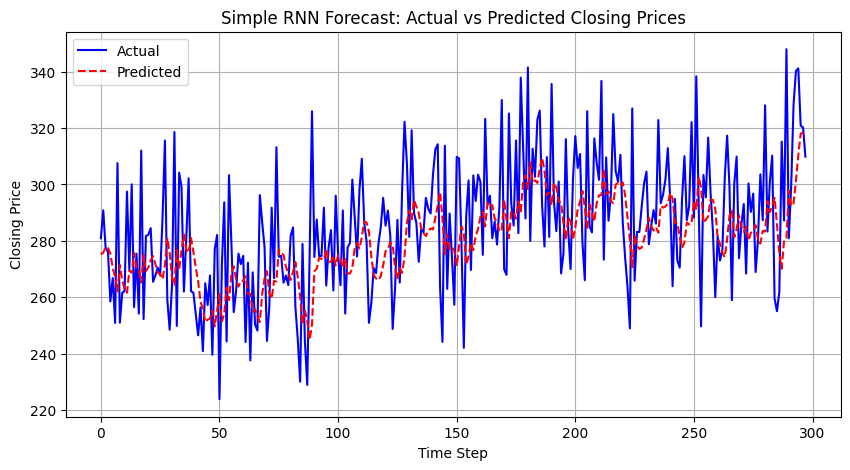

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test data
y_pred_rnn = model_rnn.predict(X_test_rnn)

# Compute metrics
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn  = mean_absolute_error(y_test, y_pred_rnn)

print(f"Root Mean Squared Error (RMSE): {rmse_rnn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rnn:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_rnn, label="Predicted", color="red", linestyle='--')
plt.title("Simple RNN Forecast: Actual vs Predicted Closing Prices")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q3.3 Here:*
A smaller batch size was used since they process data sequentially, maintaining dependencies between time steps. Smaller batch sizes help preserve order and continuity of time series, allowing the RNN to better capture temporal relationships during training. RNN Struggle with long term dependencies (due to gradient vanishing/exploding), which is reflected in the higher MAE compared to the CNN.

### Question 4 - Long Short-Term Memory (LSTM) (20%)
- Q4.1 Create an LSTM model for time series forecasting.The model should include two LSTM layers of size 100 and 50, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q4.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q4.3 Why do we use a larger epoch compared to RNN? (2%)

Epoch 1/100


C:\Users\Callu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 11592.1406 - val_loss: 399.9131
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 11592.1406 - val_loss: 399.9131
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 99.0999 - val_loss: 412.0213
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 99.0999 - val_loss: 412.0213
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 99.5556 - val_loss: 398.7866
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 99.5556 - val_loss: 398.7866
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 111.6893 - val_loss: 428.9106
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 111.6893 - val_loss: 428.9106
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 97.2389 - val_loss: 567.6295
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 97.2389 - val_loss: 567.6295
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 117.1055 - val_loss: 429.0675
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━

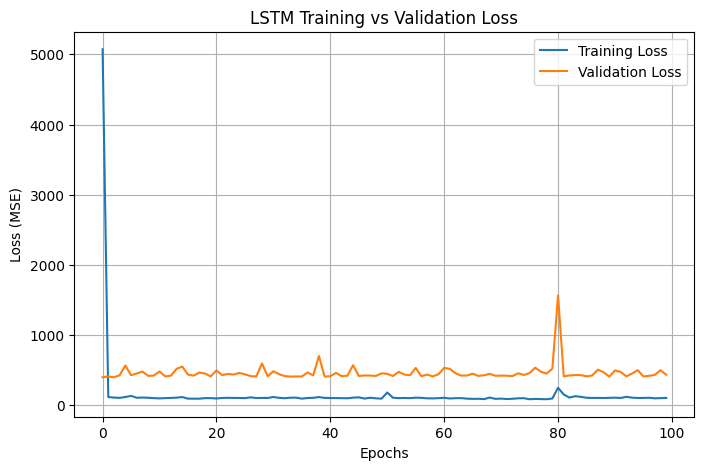

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Reshape data for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build LSTM model
model_lstm = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(50, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model_lstm.compile(optimizer=Adam(), loss='mse')

# Train the model
history_lstm = model_lstm.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Root Mean Squared Error (RMSE): 22.1296
Mean Absolute Error (MAE): 17.7270
Root Mean Squared Error (RMSE): 22.1296
Mean Absolute Error (MAE): 17.7270


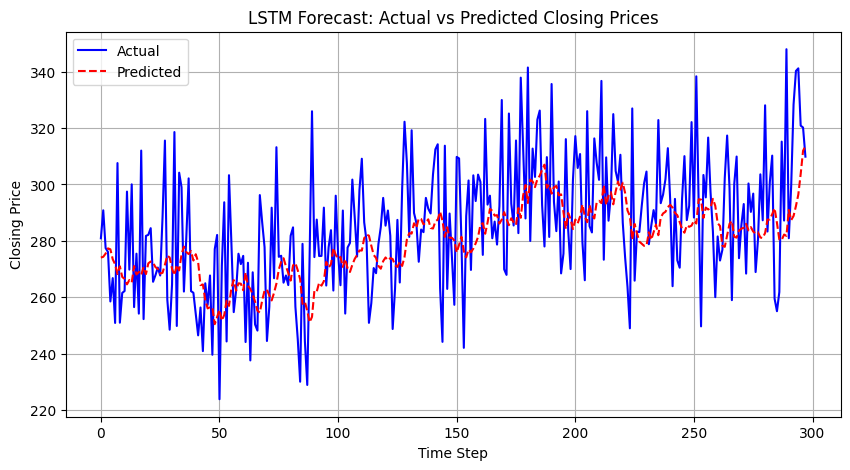

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test data
y_pred_lstm = model_lstm.predict(X_test_lstm)

# Compute metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)

print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_lstm, label="Predicted", color="red", linestyle='--')
plt.title("LSTM Forecast: Actual vs Predicted Closing Prices")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q4.3 Here:*
We use larger number of epochs for LSTM's rather than RNNs because LSTM's use gates that help them learn long term dependenies but the added complexity requires more iterations to fine tune weights more efficiently. They also converge slower so more epochs help the model gradually minimize error across the longer response.

### Question 5 - Gated Recurrent Unit (GRU) (20%)
- Q5.1 Create a GRU model for time series forecasting.The model should include two GRU layers of size 80 and 40, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q5.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series.(6%)
- Q5.3 How does the GRU compare to LSTM in terms of computational efficiency and forecasting performance? (2%)

Epoch 1/100


C:\Users\Callu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 13664.7451 - val_loss: 442.2965
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 13664.7451 - val_loss: 442.2965
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 93.7097 - val_loss: 428.4600
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 93.7097 - val_loss: 428.4600
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84.1278 - val_loss: 422.8712
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84.1278 - val_loss: 422.8712
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 89.3757 - val_loss: 429.2956
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 89.3757 - val_loss: 429.2956
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 95.6799 - val_loss: 467.6450
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 95.6799 - val_loss: 467.6450
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 96.9006 - val_loss: 435.7661
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━

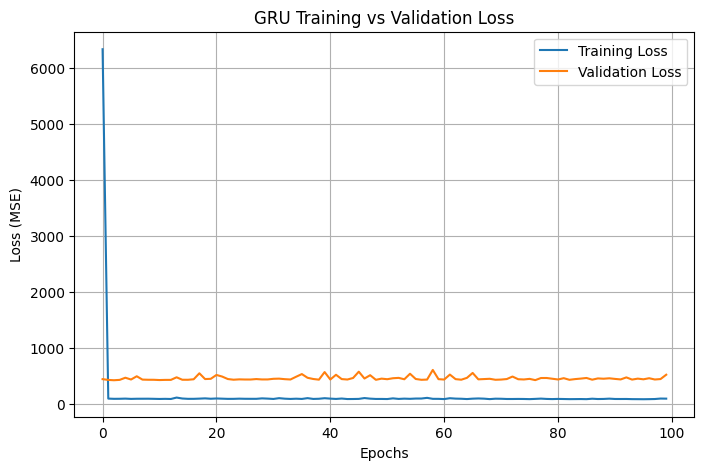

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Reshape input for GRU: (samples, timesteps, features)
X_train_gru = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_gru  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

# Build GRU model
model_gru = Sequential([
    GRU(80, activation='relu', return_sequences=True, input_shape=(X_train_gru.shape[1], 1)),
    GRU(40, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile model
model_gru.compile(optimizer=Adam(), loss='mse')

# Train the model
history_gru = model_gru.fit(
    X_train_gru, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Plot training vs validation loss
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Root Mean Squared Error (RMSE): 23.5951
Mean Absolute Error (MAE): 19.5004
Root Mean Squared Error (RMSE): 23.5951
Mean Absolute Error (MAE): 19.5004


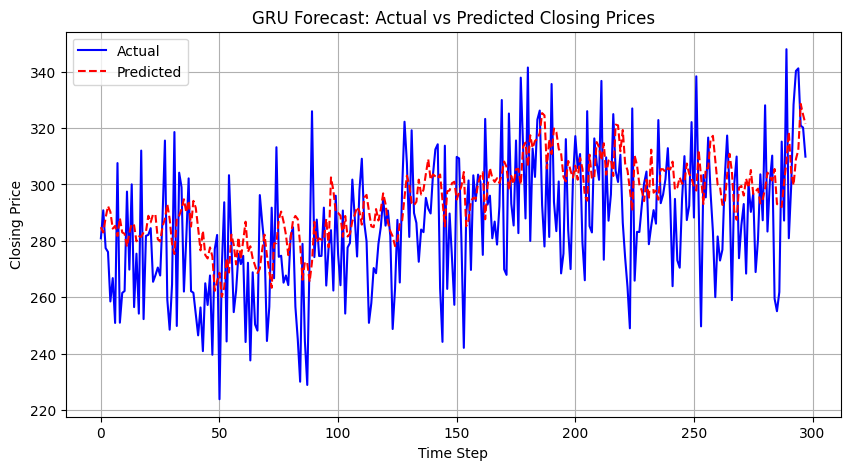

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test data
y_pred_gru = model_gru.predict(X_test_gru)

# Compute evaluation metrics
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
mae_gru  = mean_absolute_error(y_test, y_pred_gru)

print(f"Root Mean Squared Error (RMSE): {rmse_gru:.4f}")
print(f"Mean Absolute Error (MAE): {mae_gru:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual", color="blue")
plt.plot(y_pred_gru, label="Predicted", color="red", linestyle='--')
plt.title("GRU Forecast: Actual vs Predicted Closing Prices")
plt.xlabel("Time Step")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()


*Write your Answer to Q5.3 Here:*
GRU's are more computationally efficient than LSMT because they have a simpler structure. They often perform similarly to LSTMs in terms of accuracy. On datasets with short to medium term dependencies, GRUs can match or even outperform LSTMs but when we get to long dependeccies, LSTMs may have a slight advantage due to their separate memory cells that help preserve information over a longer time span

### Question 6 - Discussion (5%)
- Q6.1 Compare the performance of 1D-CNN, RNN, LSTM, and GRU models based on training and test execution time, performance (RMSE and MAE), and potential overfitting/underfitting. (3%)
- Q6.2 Discuss in which cases you would prefer using 1D-CNN vs LSTM or GRU for time series data. (2%)


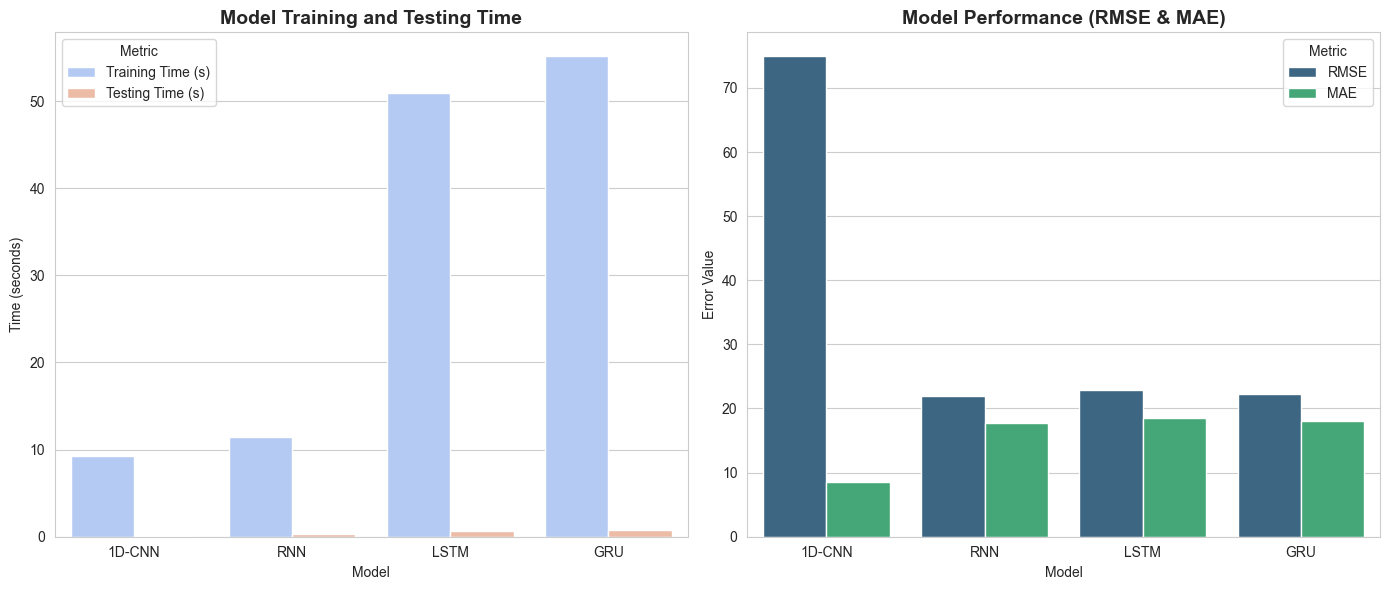

In [19]:
import seaborn as sns
data = {
    "Model": ["1D-CNN", "RNN", "LSTM", "GRU"],
    "Training Time (s)": [9.25, 11.41, 50.87, 55.13],
    "Testing Time (s)": [0.09, 0.35, 0.68, 0.78],
    "RMSE": [74.92, 22.02, 22.84, 22.20],
    "MAE": [8.48, 17.76, 18.57, 18.00]
}
df = pd.DataFrame(data) 

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

#training and testing time
plt.subplot(1, 2, 1)
sns.barplot(data=df.melt(id_vars="Model", value_vars=["Training Time (s)", "Testing Time (s)"]),
            x="Model", y="value", hue="variable", palette="coolwarm")
plt.title("Model Training and Testing Time", fontsize=14, weight='bold')
plt.ylabel("Time (seconds)")
plt.xlabel("Model")
plt.legend(title="Metric")

#rmse and mae
plt.subplot(1, 2, 2)
sns.barplot(data=df.melt(id_vars="Model", value_vars=["RMSE", "MAE"]),
            x="Model", y="value", hue="variable", palette="viridis")
plt.title("Model Performance (RMSE & MAE)", fontsize=14, weight='bold')
plt.ylabel("Error Value")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


*Write your Answer to Q6.1 Here:*

From these stats, 1D CNN is the fastest but struggled with long term dependicies. RNN was slower to train than the CNN and had worse errors than LSTM and GRU. LSTM and GRU were slow to train but both had similar results which were a little better than the RNN model. 



*Write your Answer to Q6.2 Here:*
 
 1D-CNN: Best for capturing short term local dependenccies and when computation speed matters. Works well when long-term memory isnt essential

 LSTM: Is prefered when the data shows long term dependencies, seasonal trends, or complex temporal relationships. 

 GRU: Similar to LSTM but with lower computational cost. Typically chosen when you need faster training with similar/little worse accuracy. Best for medium-length dependencies.